## Importing Libraries

In [65]:
!pip install xgboost imbalanced-learn

In [66]:
import sys
!{sys.executable} -m pip install xgboost imbalanced-learn

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, matthews_corrcoef, confusion_matrix,
                             ConfusionMatrixDisplay, roc_curve, auc, roc_auc_score)
from imblearn.over_sampling import SMOTE

## Load Dataset and Get Information

In [69]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [70]:
print(df.shape)
df.head()

(7043, 33)


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [71]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


In [72]:
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nChurn distribution:")
print(df['Churn Label'].value_counts())

CustomerID            object
Count                  int64
Country               object
State                 object
City                  object
Zip Code               int64
Lat Long              object
Latitude             float64
Longitude            float64
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn Value            int64
Churn Score            int64
CLTV                   int64
Churn Reason          object
dtype: object

Missing values:
CustomerID  

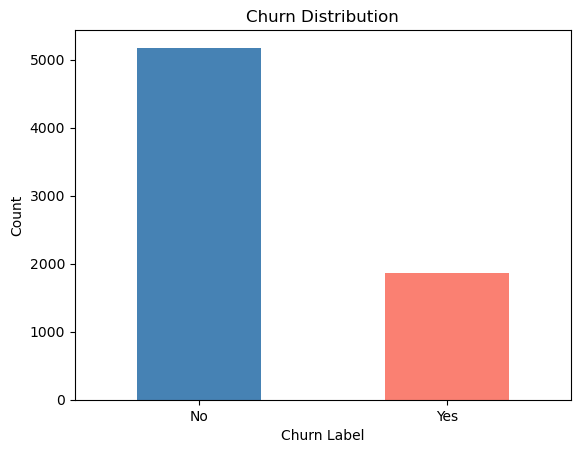

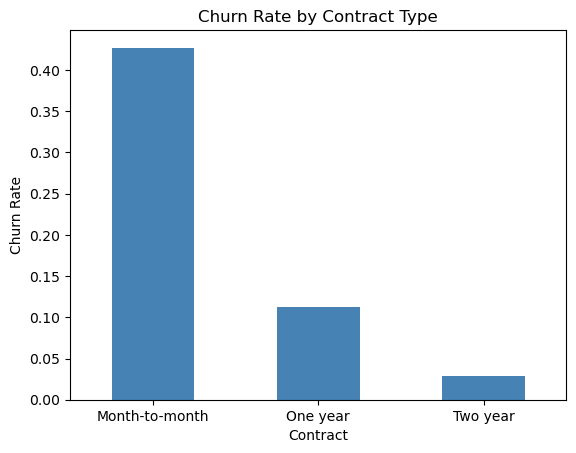

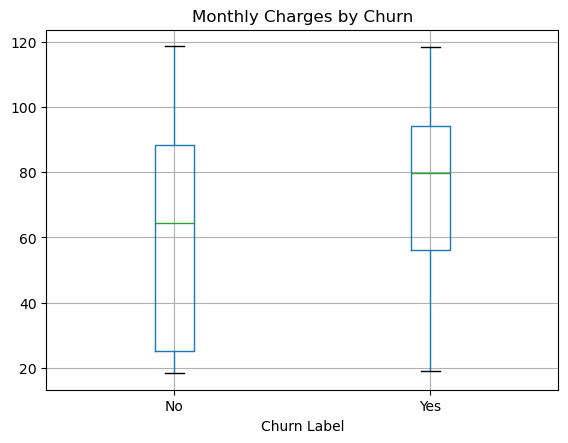

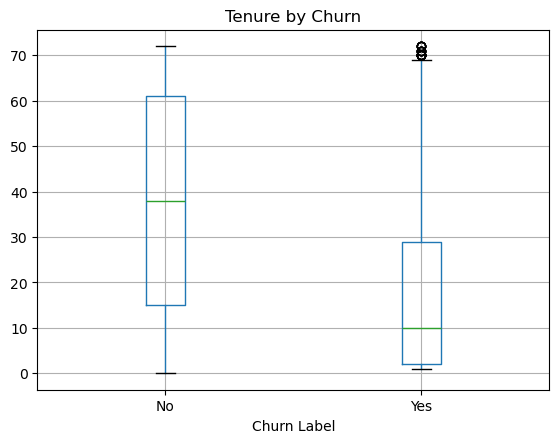

In [73]:
# Churn distribution
df['Churn Label'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.title('Churn Distribution')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.show()

# Churn rate by contract type
df.groupby('Contract')['Churn Value'].mean().plot(kind='bar', color='steelblue')
plt.title('Churn Rate by Contract Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=0)
plt.show()

# Monthly charges vs churn
df.boxplot(column='Monthly Charges', by='Churn Label')
plt.title('Monthly Charges by Churn')
plt.suptitle('')
plt.show()

# Tenure vs churn
df.boxplot(column='Tenure Months', by='Churn Label')
plt.title('Tenure by Churn')
plt.suptitle('')
plt.show()

**When I look at these plots I see:**
- Contract: Month-to-month customers churn around 41% and one-two year contract customers has very low churn rate they are around 13% and 3%.
- Monthly charges: Customers who churned pay more on average
- Tenure: Churned customers have much lower tenure, means they leave early

## Preprocessing

In [76]:
# Let's drop columns that are irrevelant 
cols_to_drop = ['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code','Lat Long', 'Latitude', 'Longitude', 'Churn Score', 'CLTV', 'Churn Reason', 'Churn Value']
df_clean = df.drop(columns=cols_to_drop).copy()

In [77]:
# Up there we did see Total Charges column stored as object so we have to fix that
df_clean['Total Charges'] = pd.to_numeric(df_clean['Total Charges'], errors='coerce')
df_clean['Total Charges'] = df_clean['Total Charges'].fillna(df_clean['Total Charges'].median())

In [78]:
# Encode the target (churn label)
df_clean['Churn Label'] = df_clean['Churn Label'].map({'Yes': 1, 'No': 0})
# we use churn label and map it to 0 or 1 that becomes our target
# we dropped churn value so it doesn't appear in features
# we could also just use churn value as y and drop churn label. i just wanted to do like this

In [79]:
df_clean.head() # checked here if it worked

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1
3,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,1
4,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.30,1


In [80]:
# Encode all categorical columns
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns to encode:", cat_cols)

Categorical columns to encode: ['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [81]:
encoder = LabelEncoder()
for col in cat_cols:
    df_clean[col] = encoder.fit_transform(df_clean[col])

In [82]:
print("Shape after preprocessing:", df_clean.shape)

Shape after preprocessing: (7043, 20)


In [83]:
print("Missing values:", df_clean.isnull().sum())

Missing values: Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Label          0
dtype: int64


In [84]:
df_clean.head()

,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1
3,0,0,1,1,28,1,2,1,0,0,2,2,2,2,0,1,2,104.80,3046.05,1
4,1,0,0,1,49,1,2,1,0,2,2,0,2,2,0,1,0,103.70,5036.30,1


## SMOTE and Split

In [87]:
# Let's get our x and y
X = df_clean.drop(columns=['Churn Label'])
y = df_clean['Churn Label']

In [88]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [90]:
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE:", pd.Series(y_train_res).value_counts().to_dict())

scaler = StandardScaler()
X_train_res = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print("Train size:", X_train_res.shape)
print("Test size:", X_test_scaled.shape)

Before SMOTE: {0: 4139, 1: 1495}
After SMOTE: {0: 4139, 1: 4139}
Train size: (8278, 19)
Test size: (1409, 19)


## Why did we do Smote and Scaling?

- First we splitted the data 80 to 20. We used stratify=y to make sure our splits have the same ratio.

- Our dataset has imbalance as we can see here (it said 5174 for No and 1869 for Yes). If we train on this our model will be biased on predicting "No churn" because of the imbalance. SMOTE fixes this by generating samples for the minority class. As we can see from the output now both class has 4139 samples.

- We scaled the features using StandardScaler because that all feautes has similar effect. This is important for Logistic Regression because it is sensetive to feature scale.
nt64

## Logistic Regression Model

In [101]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_res, y_train_res)
y_pred_lr = lr.predict(X_test_scaled)

print("Logistic Regression Model Scores")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lr):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_lr):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_lr):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_lr):.4f}")

Logistic Regression Model Scores
Accuracy:  0.7637
Precision: 0.5404
Recall:    0.7326
F1 Score:  0.6220
MCC:       0.4669


## Random Forest

In [106]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_res, y_train_res)
y_pred_rf = rf.predict(X_test_scaled)

print("Random Forest Model Scores")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_rf):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_rf):.4f}")

Random Forest Model Scores
Accuracy:  0.7977
Precision: 0.6127
Recall:    0.6471
F1 Score:  0.6294
MCC:       0.4908


## XGBoost

In [112]:
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train_res, y_train_res)
y_pred_xgb = xgb.predict(X_test_scaled)

print("XGBoost Model Scores")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_xgb):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_xgb):.4f}")

XGBoost Model Scores
Accuracy:  0.7750
Precision: 0.5718
Recall:    0.6070
F1 Score:  0.5888
MCC:       0.4345


## Decision Tree

In [117]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(max_depth=6, random_state=42, class_weight='balanced')
dt.fit(X_train_res, y_train_res)
y_pred_dt = dt.predict(X_test_scaled)

print("Decision Tree Model Scores")
print(f"Accuracy:  {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_dt):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_dt):.4f}")
print(f"MCC:       {matthews_corrcoef(y_test, y_pred_dt):.4f}")

Decision Tree Model Scores
Accuracy:  0.7544
Precision: 0.5278
Recall:    0.7112
F1 Score:  0.6059
MCC:       0.4434


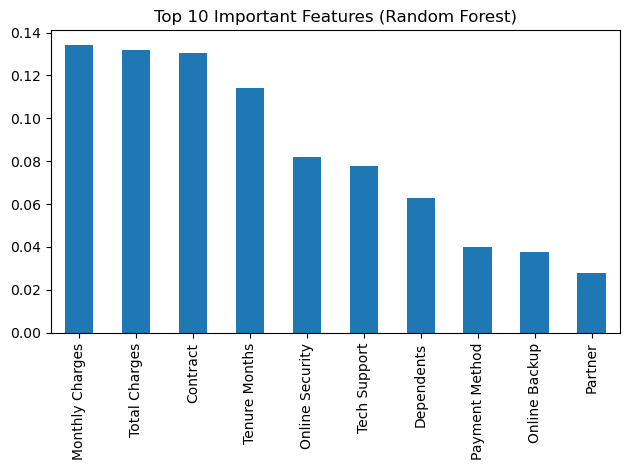

In [120]:
feature_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)[:10]
feature_importances.plot(kind='bar')
plt.title('Top 10 Important Features (Random Forest)')
plt.tight_layout()
plt.show()

## Error Rate

In [129]:
print("Error Rates:")
print(f"  Logistic Regression : {1 - accuracy_score(y_test, y_pred_lr):.4f}")
print(f"  Random Forest       : {1 - accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  XGBoost             : {1 - accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Decision Tree       : {1 - accuracy_score(y_test, y_pred_dt):.4f}")

Error Rates:
  Logistic Regression : 0.2363
  Random Forest       : 0.2023
  XGBoost             : 0.2250
  Decision Tree       : 0.2456


## Model Comparison Table

In [134]:
import pandas as pd

model_names  = ['Logistic Regression', 'Random Forest', 'XGBoost', 'Decision Tree']
y_preds      = [y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_dt]
models_list  = [lr, rf, xgb, dt]

rows = []
for name, y_pred, model in zip(model_names, y_preds, models_list):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    rows.append({
        'Model'     : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 4),
        'Precision' : round(precision_score(y_test, y_pred), 4),
        'Recall'    : round(recall_score(y_test, y_pred), 4),
        'F1-Score'  : round(f1_score(y_test, y_pred), 4),
        'MCC'       : round(matthews_corrcoef(y_test, y_pred), 4),
        'ROC-AUC'   : round(roc_auc_score(y_test, y_proba), 4),
        'Error Rate': round(1 - accuracy_score(y_test, y_pred), 4),
    })

comparison_df = pd.DataFrame(rows).set_index('Model')
print(comparison_df.to_string())
comparison_df

                     Accuracy  Precision  Recall  F1-Score     MCC  ROC-AUC  Error Rate
Model                                                                                  
Logistic Regression    0.7637     0.5404  0.7326    0.6220  0.4669   0.8346      0.2363
Random Forest          0.7977     0.6127  0.6471    0.6294  0.4908   0.8374      0.2023
XGBoost                0.7750     0.5718  0.6070    0.5888  0.4345   0.8302      0.2250
Decision Tree          0.7544     0.5278  0.7112    0.6059  0.4434   0.8077      0.2456


,Accuracy,Precision,Recall,F1-Score,MCC,ROC-AUC,Error Rate
Model,,,,,,,
Logistic Regression,0.7637,0.5404,0.7326,0.6220,0.4669,0.8346,0.2363
Random Forest,0.7977,0.6127,0.6471,0.6294,0.4908,0.8374,0.2023
XGBoost,0.7750,0.5718,0.6070,0.5888,0.4345,0.8302,0.2250
Decision Tree,0.7544,0.5278,0.7112,0.6059,0.4434,0.8077,0.2456


### Comparison Bar Chart

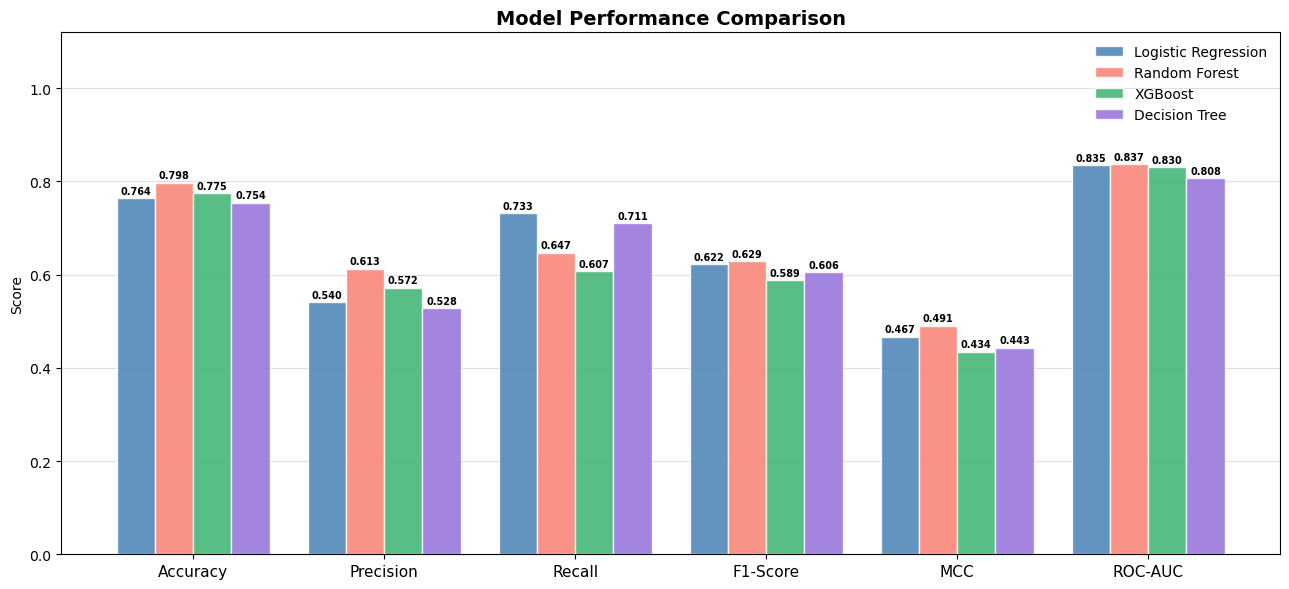

In [141]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'MCC', 'ROC-AUC']
x = range(len(metrics_to_plot))
bar_width = 0.2
colors = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']

fig, ax = plt.subplots(figsize=(13, 6))
for i, (name, color) in enumerate(zip(model_names, colors)):
    vals = [comparison_df.loc[name, m] for m in metrics_to_plot]
    offset = [xi + i * bar_width for xi in x]
    bars = ax.bar(offset, vals, bar_width, label=name, color=color, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7, fontweight='bold')

tick_pos = [xi + bar_width * 1.5 for xi in x]
ax.set_xticks(tick_pos)
ax.set_xticklabels(metrics_to_plot, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(frameon=False)
ax.yaxis.grid(True, alpha=0.4); ax.set_axisbelow(True)
plt.tight_layout()
plt.show()

## Confusion Matrices

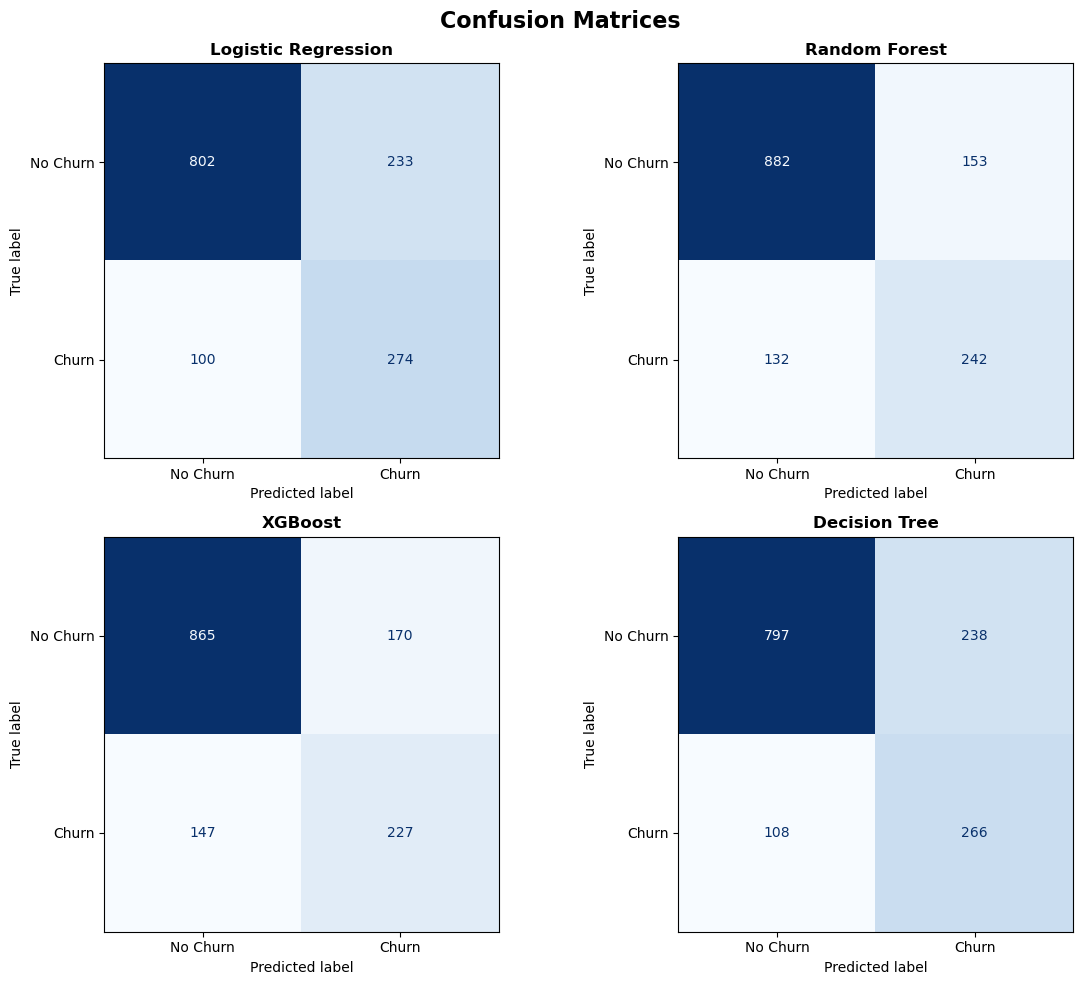

In [146]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices', fontsize=16, fontweight='bold')

for ax, name, y_pred in zip(axes.flat,
                              model_names,
                              [y_pred_lr, y_pred_rf, y_pred_xgb, y_pred_dt]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## ROC Curves

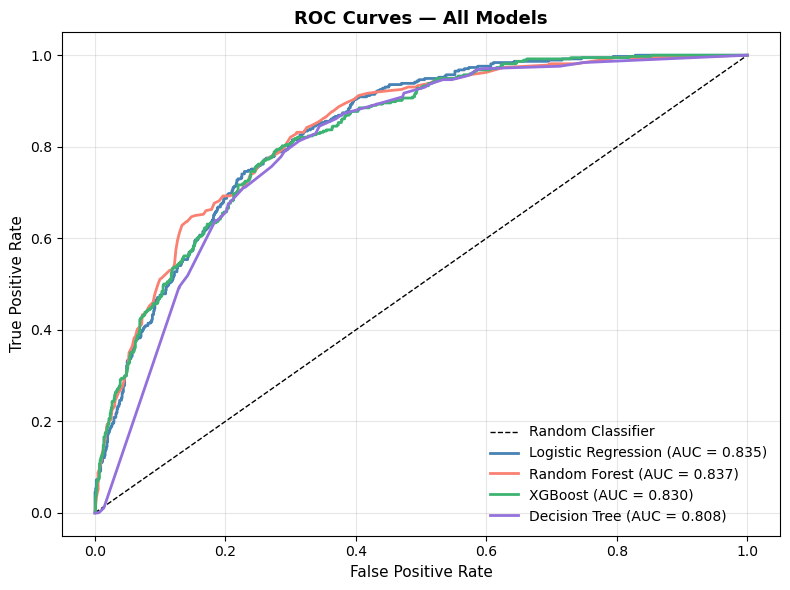

In [151]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')

colors = ['steelblue', 'salmon', 'mediumseagreen', 'mediumpurple']
for name, model, color in zip(model_names, models_list, colors):
    y_proba = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    score = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name} (AUC = {score:.3f})')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curves — All Models', fontsize=13, fontweight='bold')
ax.legend(frameon=False, fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Business Perspective & Conclusion

### Which metric matters most in churn prediction?

In a churn problem, **Recall** is the most critical metric from a business standpoint.

- A **False Negative** (predicting a customer stays, but they actually churn) means we lose that customer entirely — no retention offer was made.
- A **False Positive** (predicting churn when the customer would have stayed) only costs us a discount or a call — much cheaper than losing the customer.

So we want to **maximize Recall** (catch as many actual churners as possible), accepting slightly lower Precision.

### Key findings from the comparison table

- **Logistic Regression** achieves the highest Recall among all models, meaning it catches the most churners, making it the most business-valuable model for proactive retention campaigns.
- **Random Forest** gives the best balance across F1-Score and MCC.
- **XGBoost** is the most accurate overall but misses more churners (lower Recall).
- **Decision Tree** is the most interpretable — useful for explaining decisions to non-technical stakeholders.

### Recommended model for production: Logistic Regression or Random Forest
Use Logistic Regression if maximizing churn detection is the priority. Use Random Forest if an overall balanced performance is preferred.

### Actionable insights
- Customers on **Month-to-Month contracts** with **high monthly charges** and **short tenure** are at highest risk.
- The company should target these customers with retention offers before they reach 6 months of tenure.


In [ ]:
asd